# Project Overview
This project implements and compares filter and wrapper feature selection methods for classification problems.

The objective is to:

- reduce dimensionality
- identify relevant features
- compare subset quality
- evaluate predictive performance

The following methods are implemented:

## Filter Methods

- Mutual Information
- Chi-Squared (χ²)

## Wrapper Method

- Sequential Forward Selection (SFS)

The subsets are evaluated using:

- Random Forest
- Cross-validation
- Weighted F1-score

# Imports

In [32]:
# ============================================================
# IMPORTS
# ============================================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Filter feature selection methods
from sklearn.feature_selection import (
    mutual_info_classif,
    chi2,
    SelectKBest
)

# Feature scaling
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler
)

# Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Cross-validation
from sklearn.model_selection import cross_val_score

# Wrapper feature selection
from mlxtend.feature_selection import SequentialFeatureSelector as SFS

# Load Dataset

In [33]:
# ============================================================
# LOAD DATASET
# ============================================================

# Load CSV dataset

df = pd.read_csv("00-train.csv")

print("="*60)
print("DATASET LOADED")
print("="*60)

print(df.head())

DATASET LOADED
  Class  MIC_GOWAWA[0.6;1;S-OWA;1.0;0.0;2;W-OWA;0.9;1.0]_H_cdch  \
0   APP                                           0.403175        
1   APP                                           0.496432        
2   APP                                           0.497959        
3   APP                                           0.499336        
4   APP                                           0.507142        

   TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_T_cdch  TS[1]_SIC_T_scm  \
0                                                2.0               0.869991   
1                                                2.0               0.931745   
2                                                1.0               0.736937   
3                                                1.0               0.906529   
4                                                1.0               0.879855   

   GV[4]_CHOQUET[A;-0.75;AO1;0.9]_H_pah  GV[1]_HM_H_pah  \
0                              0.407078        1

# Features and Target

In [34]:
# ============================================================
# FEATURES AND TARGET
# ============================================================

# X:
# feature matrix

# y:
# target labels

X = df.drop(columns=["Class"])
y = df["Class"]

print("\n" + "="*60)
print("DATASET DIMENSIONS")
print("="*60)

print("X shape:", X.shape)
print("y shape:", y.shape)


DATASET DIMENSIONS
X shape: (198, 95)
y shape: (198,)


# Configuration

In [35]:
# ============================================================
# CONFIGURATION
# ============================================================

# Number of features to keep
TOP_K = 10

print("Top features selected:", TOP_K)

Top features selected: 10


# Filter Method — Mutual Information
## Theory
Mutual Information measures how much information a feature provides about the target class.

High score:
- important feature
- strong dependency with the target

Low score:
- weak dependency
- low relevance

Mutual Information can detect:

- linear relationships
- non-linear relationships

# Scaling for Mutual Information

In [36]:
# ============================================================
# FEATURE SCALING — MUTUAL INFORMATION
# ============================================================

# StandardScaler transforms features so that:
#
# mean = 0
# standard deviation = 1

scaler_mi = StandardScaler()

# fit:
# learns mean and std
#
# transform:
# applies scaling

X_scaled_mi = scaler_mi.fit_transform(X)

print("Mutual Information scaling completed.")

Mutual Information scaling completed.


# Compute Mutual Information Scores

In [37]:
# ============================================================
# MUTUAL INFORMATION SCORES
# ============================================================

mi_scores = mutual_info_classif(
    X_scaled_mi,
    y,
    random_state=42
)

print("Mutual Information scores computed successfully.")

Mutual Information scores computed successfully.


# Mutual Information Ranking

In [38]:
# ============================================================
# MUTUAL INFORMATION RANKING
# ============================================================

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})

# Sort from highest to lowest

mi_df = mi_df.sort_values(
    by="MI Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("TOP FEATURES — MUTUAL INFORMATION")
print("="*60)

print(mi_df.head(TOP_K))


TOP FEATURES — MUTUAL INFORMATION
                                             Feature  MI Score
0                                     TS[3]_Q1_T_eps  0.304955
1  TS[4]_GOWAWA[0.2;2;S-OWA;0.6;0.0;2;S-OWA;0.8;0...  0.302331
2                                     TS[2]_Q1_T_eps  0.288448
3                                       TS[4]_V_U_z3  0.285102
4                     CHOQUET[A;-0.75;AO1;1.0]_F_khh  0.279753
5                                      TS[3]_AM_F_z1  0.274131
6                      CHOQUET[A;-0.5;AO2;0.0]_N_isa  0.274077
7               GV[2]_CHOQUET[A;-0.75;AO1;0.3]_H_pah  0.269680
8  TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0....  0.267903
9               TS[3]_CHOQUET[A;-0.75;AO2;0.0]_N_scm  0.267876


# Visualization — Mutual Information

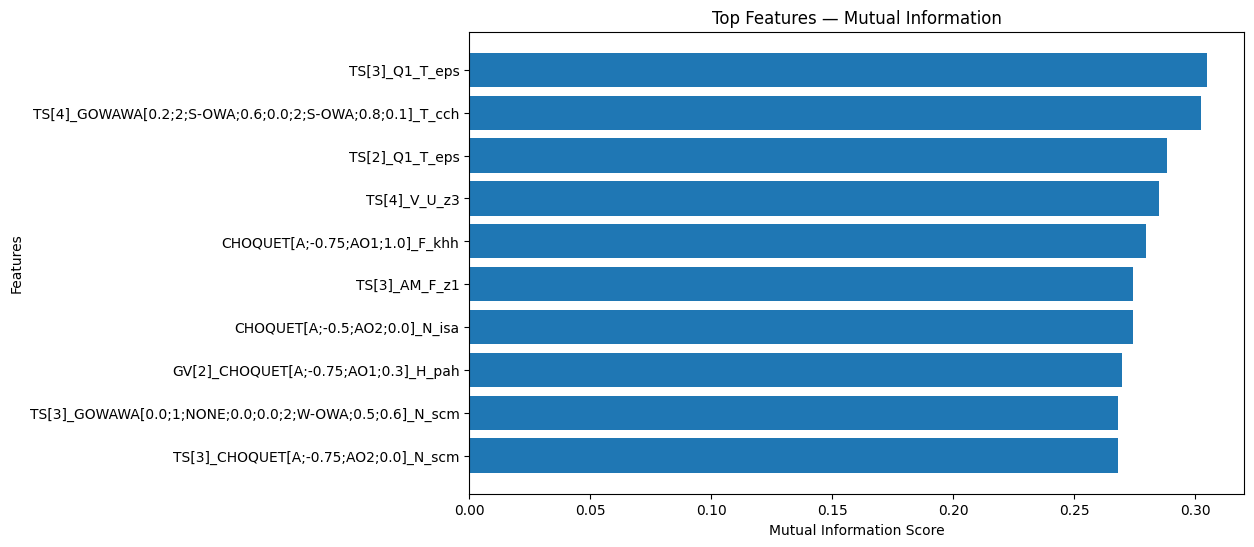

In [39]:
# ============================================================
# VISUALIZATION — MUTUAL INFORMATION
# ============================================================

# Top features

top_mi = mi_df.head(TOP_K)

plt.figure(figsize=(10,6))

plt.barh(
    top_mi["Feature"],
    top_mi["MI Score"]
)

plt.xlabel("Mutual Information Score")
plt.ylabel("Features")
plt.title("Top Features — Mutual Information")

plt.gca().invert_yaxis()

plt.show()

# Reduced Dataset — Mutual Information

In [40]:
# ============================================================
# REDUCED DATASET — MUTUAL INFORMATION
# ============================================================

# Extract top feature names

top_features_mi = mi_df.head(TOP_K)["Feature"].tolist()

# Reduced dataset

X_mi = X[top_features_mi]

print("Selected features:")
print(top_features_mi)

print("\nReduced dataset shape:")
print(X_mi.shape)

Selected features:
['TS[3]_Q1_T_eps', 'TS[4]_GOWAWA[0.2;2;S-OWA;0.6;0.0;2;S-OWA;0.8;0.1]_T_cch', 'TS[2]_Q1_T_eps', 'TS[4]_V_U_z3', 'CHOQUET[A;-0.75;AO1;1.0]_F_khh', 'TS[3]_AM_F_z1', 'CHOQUET[A;-0.5;AO2;0.0]_N_isa', 'GV[2]_CHOQUET[A;-0.75;AO1;0.3]_H_pah', 'TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0.6]_N_scm', 'TS[3]_CHOQUET[A;-0.75;AO2;0.0]_N_scm']

Reduced dataset shape:
(198, 10)


# Filter Method — Chi-Squared (χ²)
## Theory
Chi-Squared measures statistical dependency between features and the target class.

High χ² score:
- important feature
- strong relationship with target

Low χ² score:
- weak relationship
- low relevance

# Scaling for Chi²

In [41]:
# ============================================================
# FEATURE SCALING — CHI²
# ============================================================

# Chi² requires NON-NEGATIVE values.
#
# MinMaxScaler transforms all values
# into the range [0,1].

scaler_chi2 = MinMaxScaler()

X_scaled_chi2 = scaler_chi2.fit_transform(X)

print("Chi² scaling completed.")

Chi² scaling completed.


# Chi² Feature Selection

In [42]:
# ============================================================
# FEATURE SELECTION — CHI²
# ============================================================

selector = SelectKBest(
    score_func=chi2,
    k=TOP_K
)

# fit:
# computes χ² scores
#
# transform:
# keeps best features

X_chi2 = selector.fit_transform(
    X_scaled_chi2,
    y
)

print("Chi² feature selection completed.")

Chi² feature selection completed.


# Chi² Ranking

In [43]:
# ============================================================
# CHI² RANKING
# ============================================================

chi2_scores = selector.scores_

chi2_df = pd.DataFrame({
    "Feature": X.columns,
    "Chi² Score": chi2_scores
})

chi2_df = chi2_df.sort_values(
    by="Chi² Score",
    ascending=False
).reset_index(drop=True)

print("\n" + "="*60)
print("TOP FEATURES — CHI²")
print("="*60)

print(chi2_df.head(TOP_K))


TOP FEATURES — CHI²
                                             Feature  Chi² Score
0              GV[2]_CHOQUET[A;-0.75;AO2;0.7]_N_gcp1   20.134608
1  MIC_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]...   18.706284
2  TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0....   17.346977
3  TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0....   17.346233
4   GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0.6]_N_ptt   16.643749
5  TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0....   14.196119
6                                       ES_Q3_C_cdch   12.035556
7                                       TS[4]_V_U_z3   10.005441
8  TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1....    7.759669
9                      CHOQUET[A;-0.5;AO2;0.0]_N_isa    7.502742


# Visualization — Chi²

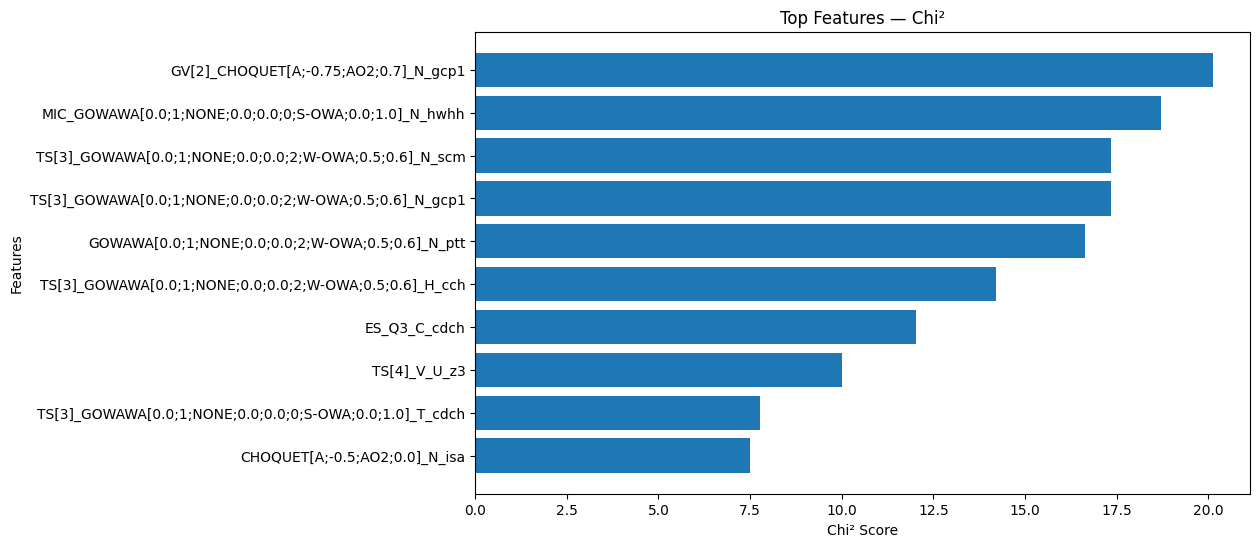

In [44]:
# ============================================================
# VISUALIZATION — CHI²
# ============================================================

# Top features

top_chi2 = chi2_df.head(TOP_K)

plt.figure(figsize=(10,6))

plt.barh(
    top_chi2["Feature"],
    top_chi2["Chi² Score"]
)

plt.xlabel("Chi² Score")
plt.ylabel("Features")
plt.title("Top Features — Chi²")

plt.gca().invert_yaxis()

plt.show()

# Reduced Dataset — Chi²

In [45]:
# ============================================================
# REDUCED DATASET — CHI²
# ============================================================

selected_idx_chi2 = selector.get_support(indices=True)

selected_features_chi2 = X.columns[selected_idx_chi2]

X_chi2_df = X[selected_features_chi2]

print("Selected features:")
print(selected_features_chi2)

print("\nReduced dataset shape:")
print(X_chi2_df.shape)

Selected features:
Index(['TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_T_cdch',
       'TS[4]_V_U_z3', 'GV[2]_CHOQUET[A;-0.75;AO2;0.7]_N_gcp1',
       'MIC_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_N_hwhh',
       'TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0.6]_H_cch',
       'TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0.6]_N_gcp1',
       'TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0.6]_N_scm',
       'ES_Q3_C_cdch', 'GOWAWA[0.0;1;NONE;0.0;0.0;2;W-OWA;0.5;0.6]_N_ptt',
       'CHOQUET[A;-0.5;AO2;0.0]_N_isa'],
      dtype='str')

Reduced dataset shape:
(198, 10)


# Wrapper Method — Sequential Forward Selection (SFS)
## Theory
Sequential Forward Selection is a wrapper feature selection method.

The algorithm:

1. starts with no variables
2. tests candidate features
3. trains a model
4. evaluates performance
5. iteratively adds the best feature

Unlike filter methods, wrappers evaluate:

- feature interactions
- model performance directly

# Scaling for SFS

In [46]:
# ============================================================
# FEATURE SCALING — SFS
# ============================================================

# Random Forest does not require scaling,
# but scaling is maintained for consistency.

scaler_sfs = StandardScaler()

X_scaled_sfs = scaler_sfs.fit_transform(X)

print("SFS scaling completed.")

SFS scaling completed.


# Random Forest Model

In [47]:
# ============================================================
# RANDOM FOREST MODEL
# ============================================================

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created.")

Random Forest model created.


# Configure SFS

In [48]:
# ============================================================
# CONFIGURE SFS
# ============================================================

sfs = SFS(

    # Model used to evaluate subsets
    estimator=rf,

    # Number of final features
    k_features=TOP_K,

    # Forward Selection
    forward=True,

    # Classical SFS
    floating=False,

    # Evaluation metric
    scoring='f1_weighted',

    # Cross-validation folds
    cv=5,

    # Use all CPU cores
    n_jobs=-1
)

print("SFS configured successfully.")

SFS configured successfully.


# Train SFS

In [49]:
# ============================================================
# TRAIN SFS
# ============================================================

print("\n" + "="*60)
print("TRAINING SFS...")
print("="*60)

sfs.fit(X_scaled_sfs, y)

print("\nSFS completed successfully.")


TRAINING SFS...

SFS completed successfully.


# SFS Results

In [50]:
# ============================================================
# SFS RESULTS
# ============================================================

# Selected indices

selected_idx = list(sfs.k_feature_idx_)

# Convert indices to real feature names

selected_features = list(
    X.columns[selected_idx]
)

# Best subset score

best_score = sfs.k_score_

# Create DataFrame

sfs_df = pd.DataFrame({
    "Feature": selected_features
})

sfs_df["SFS Score"] = best_score

print("\n" + "="*60)
print("TOP FEATURES — SFS")
print("="*60)

print(sfs_df)


TOP FEATURES — SFS
                                             Feature  SFS Score
0  TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1....    0.94448
1                                     GV[1]_HM_H_pah    0.94448
2               TS[1]_CHOQUET[D;-0.75;AO1;1.0]_C_pie    0.94448
3                                      AC[7]_HM_U_mw    0.94448
4                                         ES_SD_H_z2    0.94448
5                                      GV[3]_AM_U_z2    0.94448
6                                       ES_VC_T_gcp2    0.94448
7                                      TS[3]_AM_F_z1    0.94448
8  AC[4]_GOWAWA[0.8;1;S-OWA;1.0;0.0;1;ES2-OWA;0.9...    0.94448
9                      CHOQUET[A;-0.5;AO2;0.0]_N_isa    0.94448


# Reduced Dataset — SFS

In [51]:
# ============================================================
# REDUCED DATASET — SFS
# ============================================================

X_sfs = X[selected_features]

print("\nReduced dataset shape:")
print(X_sfs.shape)

# ============================================================
# SAVE SFS DATASET
# ============================================================

X_sfs.to_csv(
    "sfs_dataset.csv",
    index=False
)

print("SFS dataset saved successfully.")


Reduced dataset shape:
(198, 10)
SFS dataset saved successfully.


# Evaluation Function

In [52]:
# ============================================================
# REDUCED DATASET — SFS
# ============================================================

# Keep only selected features

X_sfs = X[selected_features]

print("\nReduced dataset shape:")
print(X_sfs.shape)

print("\nSelected features:")
print(selected_features)


Reduced dataset shape:
(198, 10)

Selected features:
['TS[3]_GOWAWA[0.0;1;NONE;0.0;0.0;0;S-OWA;0.0;1.0]_T_cdch', 'GV[1]_HM_H_pah', 'TS[1]_CHOQUET[D;-0.75;AO1;1.0]_C_pie', 'AC[7]_HM_U_mw', 'ES_SD_H_z2', 'GV[3]_AM_U_z2', 'ES_VC_T_gcp2', 'TS[3]_AM_F_z1', 'AC[4]_GOWAWA[0.8;1;S-OWA;1.0;0.0;1;ES2-OWA;0.9;0.0]_F_hwhh', 'CHOQUET[A;-0.5;AO2;0.0]_N_isa']


# Evaluation Function
This function evaluates feature subsets using:

- Random Forest
- Cross-validation
- Weighted F1-score

The objective is to compare the predictive performance of each subset.

In [53]:
# ============================================================
# MODEL EVALUATION FUNCTION
# ============================================================

def evaluate_model(X_data, y_data, method_name):

    # Create Random Forest model

    rf = RandomForestClassifier(
        n_estimators=100,
        random_state=42
    )

    # Perform cross-validation

    scores = cross_val_score(

        # Model
        rf,

        # Features
        X_data,

        # Target labels
        y_data,

        # Number of folds
        cv=5,

        # Evaluation metric
        scoring='f1_weighted'
    )

    # Print results

    print("\n" + "="*60)
    print(f"RANDOM FOREST — {method_name}")
    print("="*60)

    # Score per fold

    for i, score in enumerate(scores):
        print(f"Fold {i+1}: {score:.4f}")

    # Mean score

    print("\nMean F1-score:")
    print(scores.mean())

    return scores

# Evaluate Mutual Information Subset

In [54]:
# ============================================================
# EVALUATION — MUTUAL INFORMATION
# ============================================================

scores_mi = evaluate_model(

    # Mutual Information subset
    X_mi,

    # Target labels
    y,

    # Method name
    "Mutual Information"
)


RANDOM FOREST — Mutual Information
Fold 1: 0.8496
Fold 2: 0.8500
Fold 3: 0.9246
Fold 4: 0.8716
Fold 5: 0.8961

Mean F1-score:
0.8783780731018673


# Evaluate Chi² Subset

In [55]:
# ============================================================
# EVALUATION — CHI²
# ============================================================

scores_chi2 = evaluate_model(

    # Chi² subset
    X_chi2_df,

    # Target labels
    y,

    # Method name
    "Chi²"
)


RANDOM FOREST — Chi²
Fold 1: 0.8485
Fold 2: 0.8240
Fold 3: 0.8990
Fold 4: 0.8973
Fold 5: 0.8136

Mean F1-score:
0.8564799908455363


# Evaluate SFS Subset

In [56]:
# ============================================================
# EVALUATION — SFS
# ============================================================

scores_sfs = evaluate_model(

    # SFS subset
    X_sfs,

    # Target labels
    y,

    # Method name
    "Sequential Forward Selection"
)


RANDOM FOREST — Sequential Forward Selection
Fold 1: 0.9250
Fold 2: 0.9500
Fold 3: 0.9246
Fold 4: 0.9744
Fold 5: 0.9485

Mean F1-score:
0.9444804514174905


# Compare Feature Selection Methods
This section compares the performance of the feature selection methods.

The comparison includes:

- number of selected features
- predictive performance
- subset quality

In [57]:
# ============================================================
# FEATURE SELECTION COMPARISON
# ============================================================

comparison_df = pd.DataFrame({

    "Method": [

        "Mutual Information",
        "Chi²",
        "SFS"
    ],

    "Number of Features": [

        len(top_features_mi),
        len(selected_features_chi2),
        len(selected_features)
    ],

    "Mean F1-Score": [

        scores_mi.mean(),
        scores_chi2.mean(),
        scores_sfs.mean()
    ]
})

print("\n" + "="*60)
print("FEATURE SELECTION COMPARISON")
print("="*60)

print(comparison_df)


FEATURE SELECTION COMPARISON
               Method  Number of Features  Mean F1-Score
0  Mutual Information                  10       0.878378
1                Chi²                  10       0.856480
2                 SFS                  10       0.944480


# Visualization — Method Comparison

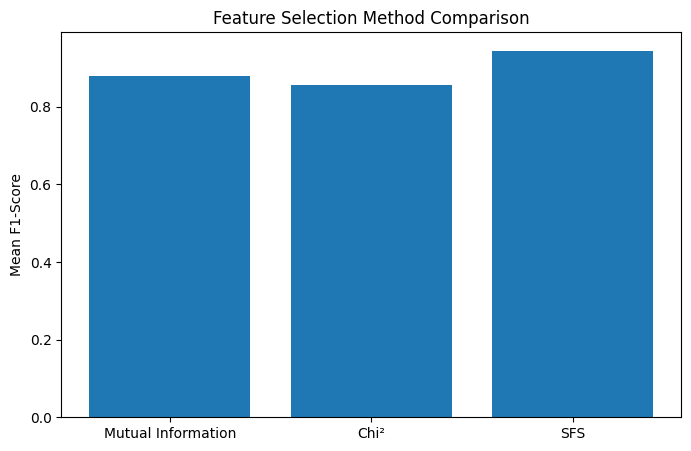

In [58]:
# ============================================================
# VISUALIZATION — METHOD COMPARISON
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df["Method"],
    comparison_df["Mean F1-Score"]
)

plt.ylabel("Mean F1-Score")
plt.title("Feature Selection Method Comparison")

plt.show()

# Correlation Analysis
Evaluate redundancy inside selected subsets.

Highly correlated variables may contain redundant information.

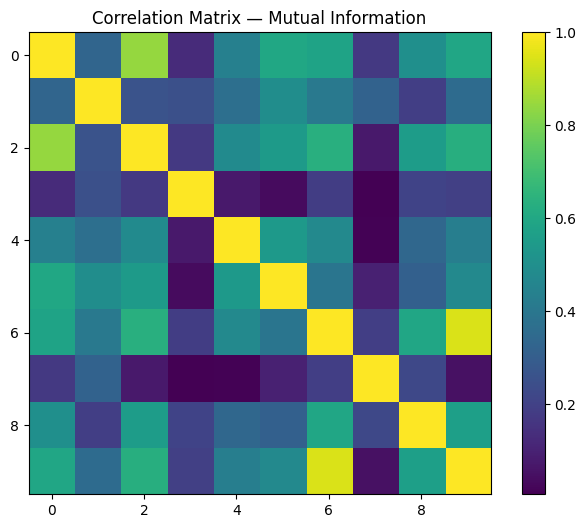

In [59]:
# ============================================================
# CORRELATION MATRIX — MUTUAL INFORMATION
# ============================================================

corr_mi = X_mi.corr().abs()

plt.figure(figsize=(8,6))

plt.imshow(corr_mi)

plt.colorbar()

plt.title("Correlation Matrix — Mutual Information")

plt.show()

# Correlation Matrix — Chi²

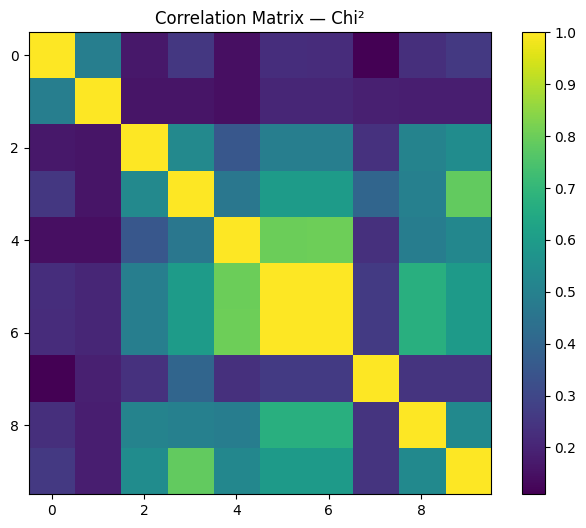

In [60]:
# ============================================================
# CORRELATION MATRIX — CHI²
# ============================================================

corr_chi2 = X_chi2_df.corr().abs()

plt.figure(figsize=(8,6))

plt.imshow(corr_chi2)

plt.colorbar()

plt.title("Correlation Matrix — Chi²")

plt.show()

# Correlation Matrix — SFS

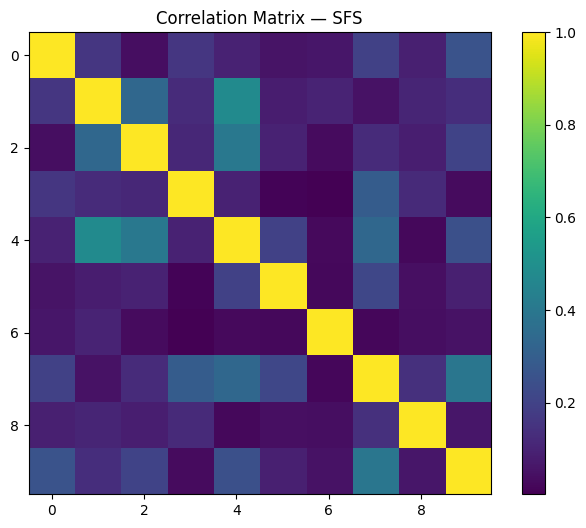

In [61]:
# ============================================================
# CORRELATION MATRIX — SFS
# ============================================================

corr_sfs = X_sfs.corr().abs()

plt.figure(figsize=(8,6))

plt.imshow(corr_sfs)

plt.colorbar()

plt.title("Correlation Matrix — SFS")

plt.show()

# Save Results

In [62]:
# ============================================================
# SAVE RESULTS
# ============================================================

# Save rankings

mi_df.to_csv(
    "mutual_information_ranking.csv",
    index=False
)

chi2_df.to_csv(
    "chi2_ranking.csv",
    index=False
)

sfs_df.to_csv(
    "sfs_ranking.csv",
    index=False
)

comparison_df.to_csv(
    "feature_selection_comparison.csv",
    index=False
)

print("Results saved successfully.")

Results saved successfully.


# Conclusions
1. Feature selection successfully reduced dimensionality.

2. Mutual Information captured linear and non-linear relationships.

3. Chi² evaluated statistical dependency with the target class.

4. SFS achieved the best predictive performance.

5. Wrapper methods produced stronger subsets but required higher computational cost.

6. Reduced subsets maintained strong classification performance.